# L14c Example: Two-channel oscillator forecasting with a MIMO HiPPO-LegS SSM
This example makes the L14c MIMO lecture concrete on a controlled synthetic signal. We generate a two-channel time series whose channels are independent sinusoids at different frequencies, train a $d_{\text{in}} = 2$, $d_{\text{out}} = 2$ MIMO HiPPO-LegS SSM to forecast the signal one step ahead, and evaluate the forecast on a held-out continuation of the same series. Because the signal is fully predictable by construction, a correctly implemented forecaster should achieve high correlation on both channels, in-sample and out-of-sample.

> __Problem statement.__ We synthesize $T$ samples of a two-channel signal $\mathbf{u}_{t} = (u_{1,t}, u_{2,t})$, where each channel is a sinusoid at its own frequency plus a small amount of observation noise. We form aligned input-target pairs with forecast horizon $k=1$, hold out the last fraction of the sequence as an OOS continuation, and train a MIMO LegS SSM on the training portion by closed-form ridge regression. We also sweep the hidden dimension $h$ and the horizon $k$ to see how forecast quality responds to each.

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Generate a controlled multi-channel synthetic signal for SSM benchmarking:__ Use superposed sinusoids at different frequencies with small additive noise to build a two-channel time series whose predictable structure you can reason about from the generating parameters.
> * __Train a MIMO HiPPO-LegS forecaster by closed-form ridge regression:__ Form the shifted input-target pair for a chosen forecast horizon, build the block-diagonal LegS filter at the appropriate hidden dimension, and fit the readout in one multi-output ridge solve.
> * __Interpret forecast performance as a function of hidden dimension and horizon:__ Read a sweep table and its associated plots, explain why the forecast correlation saturates once the basis is large enough to span the signal's bandwidth, and reason about when longer horizons make the task harder.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which sets paths, loads external packages, and pulls in the MIMO source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the `MyMimoLegSHippoModel` struct.
* [`src/Compute.jl`](src/Compute.jl) defines `build_legS_matrices_mimo`, `discretize`, `build`, `rollout`, `solve`, `fit_C!`, `predict`, and `make_forecast_pair`.
* [`src/Files.jl`](src/Files.jl) defines `save_model_checkpoint` and `load_model_checkpoint` for a `MyMimoLegSHippoModel`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating 

project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14c`


### Constants
We fix the signal generator, the hidden dimension, the forecast horizon, and the ridge penalty up front so every cell below reads from a single set of knobs.

* `T_TOTAL::Int` is the total number of samples in the synthetic series (train + test combined).
* `Δt::Float64` is the sampling step in years (1 trading day).
* `SIGNAL_FREQS::Vector{Float64}` is the pair of oscillation frequencies (cycles/yr), one per channel.
* `SIGNAL_PHASES::Vector{Float64}` is the per-channel phase offset.
* `SIGNAL_NOISE_σ::Float64` is the standard deviation of the per-sample additive noise on each channel.
* `H_OBSERVER::Int` is the per-channel LegS hidden dimension.
* `RIDGE_λ::Float64` is the ridge regularization for the closed-form $\bar{\mathbf{C}}$ solve.
* `FORECAST_HORIZON::Int` is the forecast lead time `k` in samples.
* `TRAIN_FRACTION::Float64` is the fraction of the aligned input-target pair used for training.
* `H_SWEEP::Vector{Int}` is the list of hidden dimensions used in the final sweep.
* `K_SWEEP::Vector{Int}` is the list of forecast horizons used in the final sweep.

In [ ]:
T_TOTAL           = 1200
Δt                = 1.0 / 252.0
SIGNAL_FREQS      = [3.0, 7.0]
SIGNAL_PHASES     = [0.0, π / 4]
SIGNAL_NOISE_σ    = 0.05
H_OBSERVER        = 64
RIDGE_λ           = 1.0e-4
FORECAST_HORIZON  = 1
TRAIN_FRACTION    = 0.70
H_SWEEP           = [2, 4, 8, 16, 32, 64, 128]
K_SWEEP           = [1, 2, 5, 10, 20];

___

## Task 1: Generate the two-channel oscillator data
The first task is to synthesize the two-channel signal we will forecast.

> __Signal construction.__ Each channel is a noisy sinusoid at its own frequency: $u_{j,t} = \sin(2\pi f_{j} (t\,\Delta t) + \phi_{j}) + \sigma\varepsilon_{j,t}$ for $j\in\{1, 2\}$ and $\varepsilon_{j,t}\sim\mathcal{N}(0, 1)$. The frequencies `SIGNAL_FREQS`, phases `SIGNAL_PHASES`, and noise scale `SIGNAL_NOISE_σ` set the generator; because the frequencies are different, the two channels carry independent predictable structure that a MIMO forecaster can exploit. We concatenate the per-sample vectors into a matrix $\mathbf{U}\in\mathbb{R}^{T\times 2}$ whose row $t$ is the signal at time $t$.

The code block below returns the full signal matrix as `U_full::Matrix{Float64}` of shape `(T_TOTAL, 2)` and its time axis as `t_axis::Vector{Float64}`.

In [3]:
U_full, t_axis = let
    Random.seed!(7);                                       # reproducible noise draw
    t_axis = (1:T_TOTAL) .* Δt                             # sampling instants in years
    U = zeros(Float64, T_TOTAL, 2)
    for j in 1:2
        U[:, j] = sin.(2π .* SIGNAL_FREQS[j] .* t_axis .+ SIGNAL_PHASES[j]) .+ SIGNAL_NOISE_σ .* randn(T_TOTAL)
    end
    @info "synthesized signal" shape=size(U) freqs=SIGNAL_FREQS σ=SIGNAL_NOISE_σ
    (U, t_axis)
end;

┌ Info: synthesized signal
│   shape = (1200, 2)
│   freqs =
│    2-element Vector{Float64}:
│     3.0
│     7.0
└   σ = 0.05


### Visualize the two channels
Both channels share the same time axis. We plot a window of the signal rather than the full series so the individual oscillations are visible.

In [ ]:
let
    n_show = 252                                            # first ~1 year of samples
    l = @layout [a; b]
    p1 = plot(t_axis[1:n_show], U_full[1:n_show, 1];
        label = "channel 1 (f = $(SIGNAL_FREQS[1]) cycles/yr)",
        xlabel = "time (years)", ylabel = "u_{1,t}",
        lw = 1.2, c = :deepskyblue,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    p2 = plot(t_axis[1:n_show], U_full[1:n_show, 2];
        label = "channel 2 (f = $(SIGNAL_FREQS[2]) cycles/yr)",
        xlabel = "time (years)", ylabel = "u_{2,t}",
        lw = 1.2, c = :darkorange,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the signal look like to a short-memory forecaster?__ Using only the two-panel plot above: (a) How many full oscillation periods of each channel fit in the displayed one-year window, and does that match the frequency you put in? (b) If you were trying to predict the next sample of channel 1 using only the immediate previous sample, how well could you do? How would this change if you instead used the last hundred samples? Answer without running any code.

___

## Task 2: Build and train the MIMO forecaster
The second task builds a MIMO HiPPO-LegS SSM at per-channel hidden dimension `H_OBSERVER = 64` with two input channels and two output channels, and fits the readout $\bar{\mathbf{C}}$ by closed-form ridge regression on the first `TRAIN_FRACTION` of the aligned input-target pair at horizon `FORECAST_HORIZON`.

> __Data splits.__ We first form the forecast pair $(\mathbf{U}_{\text{input}}, \mathbf{U}_{\text{target}})$ from the full signal using [`make_forecast_pair`](src/Compute.jl), which drops `FORECAST_HORIZON` rows so that row $t$ of the target is $\mathbf{u}_{t+k}$. We then split the pair into a training portion of size $\lfloor \texttt{TRAIN\_FRACTION}\cdot(T-k)\rfloor$ and a held-out continuation that the model never sees during training.

> __Model fit.__ The MIMO LegS filter has $H = h\cdot d_{\text{in}} = 64\cdot 2 = 128$ hidden dimensions. [`build`](src/Compute.jl) constructs the block-diagonal $(\mathbf{A}, \mathbf{B})$ and its bilinear-discretized counterpart $(\bar{\mathbf{A}}, \bar{\mathbf{B}})$; [`fit_C!`](src/Compute.jl) solves the stacked ridge normal equations for $\bar{\mathbf{C}}\in\mathbb{R}^{2\times 128}$ in one closed-form step. No SGD loop is needed.

The code block below stores the trained model in `model::MyMimoLegSHippoModel`, the training portion of the input-target pair as `U_in_tr::Matrix{Float64}` and `U_tgt_tr::Matrix{Float64}`, and the held-out continuation as `U_in_te::Matrix{Float64}` and `U_tgt_te::Matrix{Float64}`.

In [5]:
model, U_in_tr, U_tgt_tr, U_in_te, U_tgt_te = let
    # align input and target at the chosen forecast horizon
    (Uin, Utgt) = make_forecast_pair(U_full, FORECAST_HORIZON)
    T_pair = size(Uin, 1)

    # split into training and held-out continuation
    n_train = floor(Int, TRAIN_FRACTION * T_pair)
    U_in_tr  = Uin[1:n_train, :]
    U_tgt_tr = Utgt[1:n_train, :]
    U_in_te  = Uin[(n_train + 1):end, :]
    U_tgt_te = Utgt[(n_train + 1):end, :]

    # build the MIMO LegS filter and fit the readout on the training pair
    Random.seed!(42);
    m = build(MyMimoLegSHippoModel; h = H_OBSERVER, d_in = 2, d_out = 2, Δt = Δt)
    fit_C!(m, U_in_tr, U_tgt_tr; λ = RIDGE_λ)
    @info "trained MIMO forecaster" h=m.h d_in=m.d_in d_out=m.d_out H_total=size(m.Ā, 1) k=FORECAST_HORIZON n_train=n_train n_test=size(U_in_te, 1)
    (m, U_in_tr, U_tgt_tr, U_in_te, U_tgt_te)
end;

┌ Info: trained MIMO forecaster
│   h = 64
│   d_in = 2
│   d_out = 2
│   H_total = 128
│   k = 1
│   n_train = 839
└   n_test = 360


### In-sample forecast quality
With the readout fit, we roll the model forward on the training input to produce the in-sample forecast and check per-channel correlation and mean-squared error against the training target.

In [6]:
Ŷ_in = let
    (_, Yhat) = solve(model, U_in_tr)
    ρ1 = cor(U_tgt_tr[:, 1], Yhat[:, 1])
    ρ2 = cor(U_tgt_tr[:, 2], Yhat[:, 2])
    mse1 = mean((U_tgt_tr[:, 1] .- Yhat[:, 1]).^2)
    mse2 = mean((U_tgt_tr[:, 2] .- Yhat[:, 2]).^2)
    @info "in-sample forecast metrics" ρ_ch1=round(ρ1, digits=4) ρ_ch2=round(ρ2, digits=4) mse_ch1=round(mse1, sigdigits=4) mse_ch2=round(mse2, sigdigits=4)
    Yhat
end;

┌ Info: in-sample forecast metrics
│   ρ_ch1 = 0.998
│   ρ_ch2 = 0.9967
│   mse_ch1 = 0.00205
└   mse_ch2 = 0.003297


### Visualize the in-sample forecast
We overlay the observed target and the forecaster's prediction for each channel on a small window of the training range so the tracking is visible.

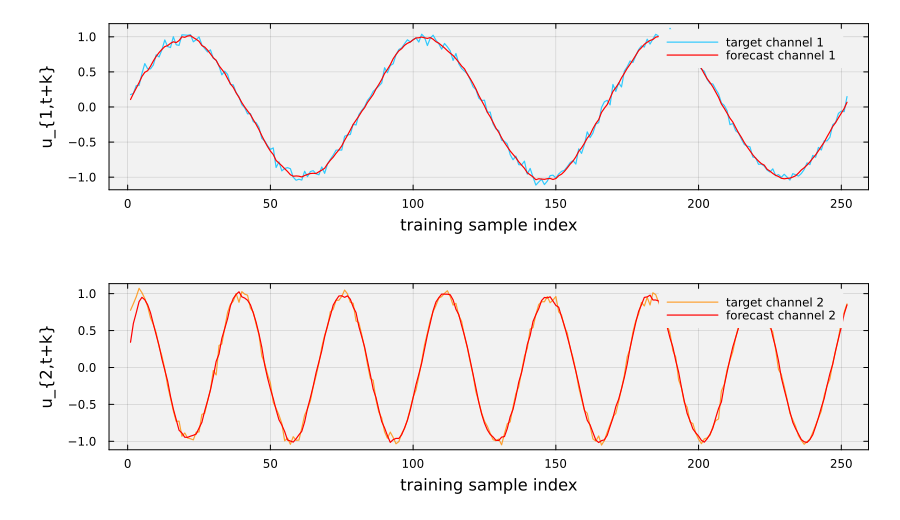

In [7]:
let
    n_show = 252
    n_show = min(n_show, size(U_tgt_tr, 1))
    l = @layout [a; b]
    p1 = plot(U_tgt_tr[1:n_show, 1];
        label = "target channel 1",
        xlabel = "training sample index", ylabel = "u_{1,t+k}",
        lw = 1.2, c = :deepskyblue, alpha = 0.8,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, Ŷ_in[1:n_show, 1]; label = "forecast channel 1", lw = 1.2, c = :red)
    p2 = plot(U_tgt_tr[1:n_show, 2];
        label = "target channel 2",
        xlabel = "training sample index", ylabel = "u_{2,t+k}",
        lw = 1.2, c = :darkorange, alpha = 0.8,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, Ŷ_in[1:n_show, 2]; label = "forecast channel 2", lw = 1.2, c = :red)
    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the in-sample fit tell you about bandwidth coverage?__ Using only the overlay plot and the `@info` metrics above: (a) do both channels achieve high correlation, and are the reconstruction errors of comparable magnitude across channels? (b) What does this imply about whether `H_OBSERVER = 64` is large enough to span the bandwidth of both sinusoids at the sampling rate we chose?

___

## Task 3: Evaluate out-of-sample and sweep hidden dimension and horizon
The third task applies the trained model to the held-out continuation (out-of-sample) and then sweeps the hidden dimension $h$ and the forecast horizon $k$ to study how forecast quality depends on each.

> __What we expect.__ Because the signal is deterministic up to a small observation noise, the in-sample and out-of-sample forecast correlations should be close to one another at every $h$ once the basis is large enough, mirroring the pattern L14a's h-sweep showed on SPY. As $h$ shrinks, the basis cannot fully span the signal's bandwidth and both correlations should drop together. As $k$ grows, the forecast task generally gets harder. For this signal, however, every horizon we sweep ($k \le 20$ samples) is shorter than either channel's oscillation period ($\approx 84$ and $36$ samples), so correlations should stay close to their $k=1$ values across the sweep rather than falling off.

### Out-of-sample forecast
The LegS basis has slow modes whose time constants can exceed one hundred samples, so resetting $\mathbf{x}_{0} = \mathbf{0}$ on the held-out split would leave the hidden state in transient long enough to distort the OOS metrics. Instead, we roll the trained `model` across the full aligned-pair input in one continuous pass and slice predictions at the train/test boundary, which keeps the hidden state warm and makes the OOS evaluation reflect genuine generalization rather than transient-recovery artifacts.

In [8]:
Ŷ_oos, U_tgt_te_eval = let
    # single rollout across the full aligned pair, then split at the training boundary
    U_full_pair = vcat(U_in_tr, U_in_te)
    (_, Yhat_full) = solve(model, U_full_pair)
    Yhat_te = Yhat_full[(size(U_in_tr, 1) + 1):end, :]
    U_eval  = U_tgt_te
    ρ1 = cor(U_eval[:, 1], Yhat_te[:, 1])
    ρ2 = cor(U_eval[:, 2], Yhat_te[:, 2])
    mse1 = mean((U_eval[:, 1] .- Yhat_te[:, 1]).^2)
    mse2 = mean((U_eval[:, 2] .- Yhat_te[:, 2]).^2)
    @info "out-of-sample forecast metrics" ρ_ch1=round(ρ1, digits=4) ρ_ch2=round(ρ2, digits=4) mse_ch1=round(mse1, sigdigits=4) mse_ch2=round(mse2, sigdigits=4) T_eval=size(U_eval, 1)
    (Yhat_te, U_eval)
end;

┌ Info: out-of-sample forecast metrics
│   ρ_ch1 = 0.9933
│   ρ_ch2 = 0.9965
│   mse_ch1 = 0.007057
│   mse_ch2 = 0.003537
└   T_eval = 360


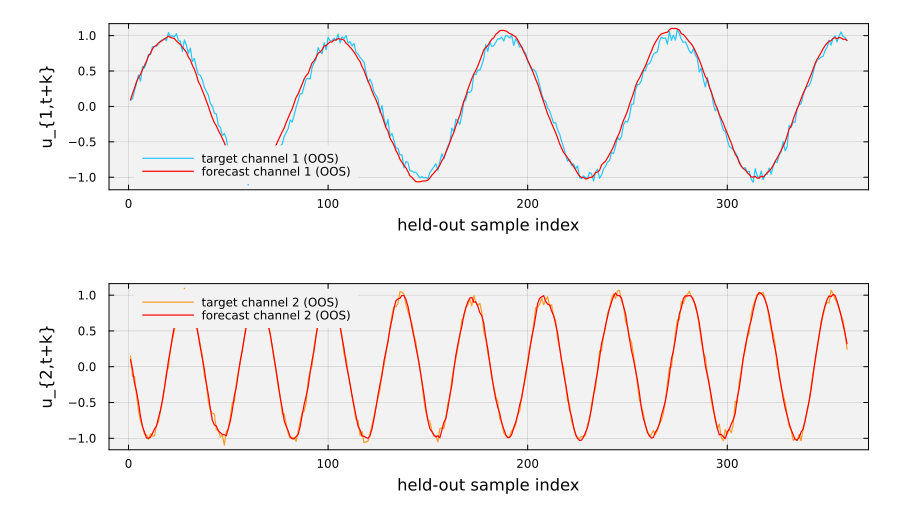

In [9]:
let
    l = @layout [a; b]
    p1 = plot(U_tgt_te_eval[:, 1];
        label = "target channel 1 (OOS)",
        xlabel = "held-out sample index", ylabel = "u_{1,t+k}",
        lw = 1.2, c = :deepskyblue, alpha = 0.85,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, Ŷ_oos[:, 1]; label = "forecast channel 1 (OOS)", lw = 1.2, c = :red)
    p2 = plot(U_tgt_te_eval[:, 2];
        label = "target channel 2 (OOS)",
        xlabel = "held-out sample index", ylabel = "u_{2,t+k}",
        lw = 1.2, c = :darkorange, alpha = 0.85,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, Ŷ_oos[:, 2]; label = "forecast channel 2 (OOS)", lw = 1.2, c = :red)
    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Hidden-dimension sweep at a fixed horizon
With the horizon pinned at `FORECAST_HORIZON`, we vary the per-channel hidden dimension and record the per-channel in-sample and out-of-sample correlation.

In [10]:
sweep_h = let
    (Uin, Utgt) = make_forecast_pair(U_full, FORECAST_HORIZON)
    T_pair = size(Uin, 1)
    n_train = floor(Int, TRAIN_FRACTION * T_pair)
    Utr  = Uin[1:n_train, :]; Ttr  = Utgt[1:n_train, :]
    Ute  = Uin[(n_train + 1):end, :]; Tte  = Utgt[(n_train + 1):end, :]

    df = DataFrame(h = Int[], ρ_tr_ch1 = Float64[], ρ_tr_ch2 = Float64[],
                              ρ_te_ch1 = Float64[], ρ_te_ch2 = Float64[])
    for h in H_SWEEP
        m = build(MyMimoLegSHippoModel; h = h, d_in = 2, d_out = 2, Δt = Δt)
        fit_C!(m, Utr, Ttr; λ = RIDGE_λ)
        # single rollout on the full input, split predictions at the training boundary
        (_, Yfull) = solve(m, vcat(Utr, Ute))
        n = size(Utr, 1)
        Yin = Yfull[1:n, :]
        Yte = Yfull[(n + 1):end, :]
        push!(df, (h,
                   cor(Ttr[:, 1], Yin[:, 1]), cor(Ttr[:, 2], Yin[:, 2]),
                   cor(Tte[:, 1], Yte[:, 1]), cor(Tte[:, 2], Yte[:, 2])))
    end
    pretty_table(df;
        backend = :text,
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

┌───────┬──────────┬──────────┬──────────┬──────────┐
│     h │ ρ_tr_ch1 │ ρ_tr_ch2 │ ρ_te_ch1 │ ρ_te_ch2 │
│ Int64 │  Float64 │  Float64 │  Float64 │  Float64 │
├───────┼──────────┼──────────┼──────────┼──────────┤
│     2 │   0.8318 │   0.6098 │   0.8653 │   0.6152 │
│     4 │   0.9616 │   0.8972 │   0.9858 │   0.9589 │
│     8 │   0.9966 │   0.9934 │   0.9967 │   0.9954 │
│    16 │   0.9975 │   0.9966 │   0.9966 │   0.9966 │
│    32 │   0.9978 │   0.9967 │   0.9962 │   0.9966 │
│    64 │    0.998 │   0.9967 │   0.9933 │   0.9965 │
│   128 │   0.9985 │   0.9969 │   0.9914 │    0.995 │
└───────┴──────────┴──────────┴──────────┴──────────┘


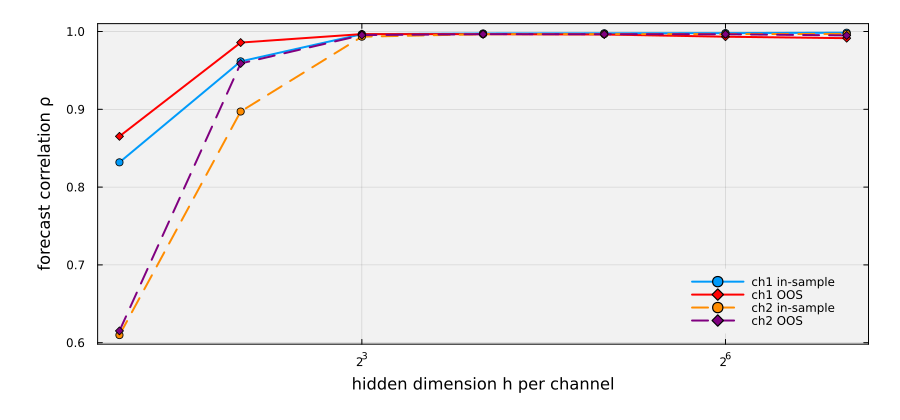

In [11]:
let
    p = plot(sweep_h.h, sweep_h.ρ_tr_ch1;
        label = "ch1 in-sample",  lw = 2, marker = :circle,
        xlabel = "hidden dimension h per channel", ylabel = "forecast correlation ρ",
        xscale = :log2, legend = :bottomright,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p, sweep_h.h, sweep_h.ρ_te_ch1; label = "ch1 OOS",  lw = 2, marker = :diamond, c = :red)
    plot!(p, sweep_h.h, sweep_h.ρ_tr_ch2; label = "ch2 in-sample", lw = 2, marker = :circle,  c = :darkorange, ls = :dash)
    plot!(p, sweep_h.h, sweep_h.ρ_te_ch2; label = "ch2 OOS", lw = 2, marker = :diamond, c = :purple, ls = :dash)
    plot(p; size = (900, 420),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Forecast-horizon sweep at a fixed hidden dimension
With the hidden dimension pinned at `H_OBSERVER`, we vary the forecast horizon $k$ and record the per-channel in-sample and out-of-sample correlation.

In [12]:
sweep_k = let
    df = DataFrame(k = Int[], ρ_tr_ch1 = Float64[], ρ_tr_ch2 = Float64[],
                              ρ_te_ch1 = Float64[], ρ_te_ch2 = Float64[])
    for k in K_SWEEP
        (Uin, Utgt) = make_forecast_pair(U_full, k)
        T_pair = size(Uin, 1)
        n_train = floor(Int, TRAIN_FRACTION * T_pair)
        Utr  = Uin[1:n_train, :]; Ttr  = Utgt[1:n_train, :]
        Ute  = Uin[(n_train + 1):end, :]; Tte  = Utgt[(n_train + 1):end, :]
        m = build(MyMimoLegSHippoModel; h = H_OBSERVER, d_in = 2, d_out = 2, Δt = Δt)
        fit_C!(m, Utr, Ttr; λ = RIDGE_λ)
        (_, Yfull) = solve(m, vcat(Utr, Ute))
        n = size(Utr, 1)
        Yin = Yfull[1:n, :]
        Yte = Yfull[(n + 1):end, :]
        push!(df, (k,
                   cor(Ttr[:, 1], Yin[:, 1]), cor(Ttr[:, 2], Yin[:, 2]),
                   cor(Tte[:, 1], Yte[:, 1]), cor(Tte[:, 2], Yte[:, 2])))
    end
    pretty_table(df;
        backend = :text,
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

┌───────┬──────────┬──────────┬──────────┬──────────┐
│     k │ ρ_tr_ch1 │ ρ_tr_ch2 │ ρ_te_ch1 │ ρ_te_ch2 │
│ Int64 │  Float64 │  Float64 │  Float64 │  Float64 │
├───────┼──────────┼──────────┼──────────┼──────────┤
│     1 │    0.998 │   0.9967 │   0.9933 │   0.9965 │
│     2 │   0.9979 │   0.9965 │   0.9942 │   0.9962 │
│     5 │   0.9976 │   0.9964 │    0.995 │   0.9961 │
│    10 │   0.9972 │   0.9976 │   0.9947 │   0.9968 │
│    20 │   0.9966 │   0.9966 │   0.9955 │   0.9962 │
└───────┴──────────┴──────────┴──────────┴──────────┘


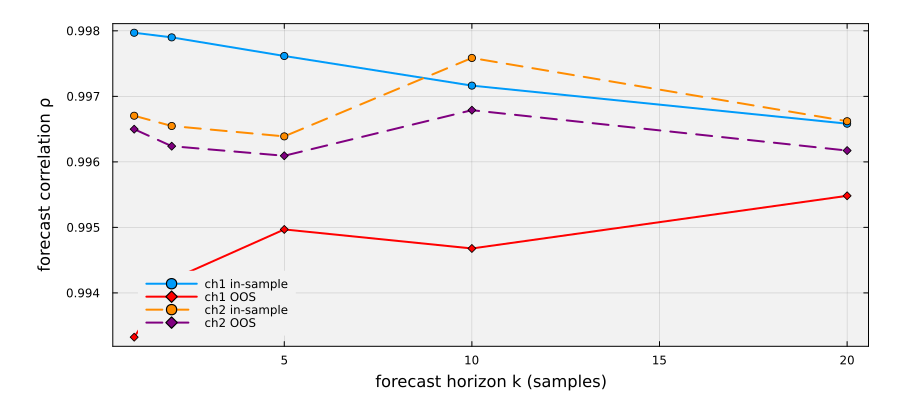

In [13]:
let
    p = plot(sweep_k.k, sweep_k.ρ_tr_ch1;
        label = "ch1 in-sample",  lw = 2, marker = :circle,
        xlabel = "forecast horizon k (samples)", ylabel = "forecast correlation ρ",
        legend = :bottomleft,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p, sweep_k.k, sweep_k.ρ_te_ch1; label = "ch1 OOS",  lw = 2, marker = :diamond, c = :red)
    plot!(p, sweep_k.k, sweep_k.ρ_tr_ch2; label = "ch2 in-sample", lw = 2, marker = :circle,  c = :darkorange, ls = :dash)
    plot!(p, sweep_k.k, sweep_k.ρ_te_ch2; label = "ch2 OOS", lw = 2, marker = :diamond, c = :purple, ls = :dash)
    plot(p; size = (900, 420),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What do the two sweeps tell you about the signal?__ Using only the two sweep tables and their plots (no retraining): (a) Does forecast correlation saturate close to one past some hidden dimension, and at roughly what value of $h$ does the saturation happen for each channel? (b) Does forecast correlation fall monotonically as $k$ grows, and do the two channels degrade at comparable rates or at different rates? Put the two observations together: for this synthetic signal, is the limiting factor the model's memory (small $h$) or the intrinsic predictability of the signal (large $k$)?

___

## Summary
This notebook fit a two-input two-output MIMO HiPPO-LegS SSM to a noisy two-channel oscillator signal, trained the readout by closed-form ridge regression on an aligned input-target pair at forecast horizon one, and evaluated on a held-out continuation. The same infrastructure then let us sweep the per-channel hidden dimension and the forecast horizon to see how each knob moved the forecast correlation.

> __Key Takeaways:__
>
> * **The MIMO forecaster inherits the hidden-dimension scaling of the SISO memorize task:** As the per-channel hidden dimension grows from small to large, in-sample and out-of-sample forecast correlations rise together and saturate near one once the LegS basis can span both sinusoidal frequencies. Undersizing the basis is the dominant failure mode at small hidden dimension.
> * **Multi-output ridge is free on top of single-output ridge:** The second output channel adds no training time beyond the one-column ridge solve, because the Gram matrix is shared and only the right-hand side changes. This is why scaling from SISO to MIMO is almost trivial in practice.
> * **Forecast correlation at horizons shorter than the oscillation period stays high:** Every tested horizon ($k = 1, 2, 5, 10, 20$ samples) is shorter than either channel's oscillation period ($\approx 84$ and $36$ samples), so the forecaster stays inside the regime where the signal remains highly predictable and correlations hold near one across the sweep. For horizons much longer than the period, or for signals with shorter decorrelation times, correlation would fall toward zero.

___